<a href="https://colab.research.google.com/github/alessiomartini/learning_statistical_learning/blob/main/Finance_101_1_Stocks_Data_Analysis_and_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#TASK #1: PROBLEM STATEMENT AND PROJECT OVERVIEW

![alt text](https://drive.google.com/uc?id=1qOZKOEs_N-SbkO2vqlsxpXfHAqjZLw1p)

#TASK #2: IMPORT DATASETS AND LIBRARIES

In [102]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [103]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from copy import copy
from scipy import stats
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go

In [104]:
# Read the stock data csv file, here's the list of the stocks considered:

stocks_df = pd.read_csv('sample_data/stock.csv')
stocks_df

# AAPL = Apple Stock
# BA = Boeing
# T = AT&T
# MGM = MGM Resorts International (Hotel Industry)
# AMZN = Amazon
# IBM = IBM
# TSLA = Tesla Motors
# GOOG = Google
# sp500 = US Stock Market (S&P 500 is a stock market index that measures the stock performance of 500 large companies listed on U.S. stock exchange)
# Check the list of S&P 500 companies here: https://en.wikipedia.org/wiki/List_of_S%26P_500_companies



,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,60.198570,75.510002,30.120001,12.130000,175.929993,180.550003,28.250000,313.644379,1295.500000
1,2012-01-13,59.972858,74.599998,30.070000,12.350000,178.419998,179.160004,22.790001,311.328064,1289.089966
2,2012-01-17,60.671429,75.239998,30.250000,12.250000,181.660004,180.000000,26.600000,313.116364,1293.670044
3,2012-01-18,61.301430,75.059998,30.330000,12.730000,189.440002,181.070007,26.809999,315.273285,1308.040039
4,2012-01-19,61.107143,75.559998,30.420000,12.800000,194.449997,180.520004,26.760000,318.590851,1314.500000
...,...,...,...,...,...,...,...,...,...,...
2154,2020-08-05,440.250000,174.279999,29.850000,16.719999,3205.030029,125.449997,1485.020020,1473.609985,3327.770020
2155,2020-08-06,455.609985,172.199997,29.840000,18.459999,3225.000000,126.120003,1489.579956,1500.099976,3349.159912
2156,2020-08-07,444.450012,170.020004,30.020000,19.030001,3167.459961,124.959999,1452.709961,1494.489990,3351.280029
2157,2020-08-10,450.910004,179.410004,30.200001,21.650000,3148.159912,127.110001,1418.569946,1496.099976,3360.469971


In [105]:
# Sort the stock data by date

stocks_df = stocks_df.sort_values(by= ['Date'])
stocks_df

,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,60.198570,75.510002,30.120001,12.130000,175.929993,180.550003,28.250000,313.644379,1295.500000
1,2012-01-13,59.972858,74.599998,30.070000,12.350000,178.419998,179.160004,22.790001,311.328064,1289.089966
2,2012-01-17,60.671429,75.239998,30.250000,12.250000,181.660004,180.000000,26.600000,313.116364,1293.670044
3,2012-01-18,61.301430,75.059998,30.330000,12.730000,189.440002,181.070007,26.809999,315.273285,1308.040039
4,2012-01-19,61.107143,75.559998,30.420000,12.800000,194.449997,180.520004,26.760000,318.590851,1314.500000
...,...,...,...,...,...,...,...,...,...,...
2154,2020-08-05,440.250000,174.279999,29.850000,16.719999,3205.030029,125.449997,1485.020020,1473.609985,3327.770020
2155,2020-08-06,455.609985,172.199997,29.840000,18.459999,3225.000000,126.120003,1489.579956,1500.099976,3349.159912
2156,2020-08-07,444.450012,170.020004,30.020000,19.030001,3167.459961,124.959999,1452.709961,1494.489990,3351.280029
2157,2020-08-10,450.910004,179.410004,30.200001,21.650000,3148.159912,127.110001,1418.569946,1496.099976,3360.469971


In [106]:
# Print out the number of stocks

print('Total Number of stocks:{}'.format(len(stocks_df.columns[1:])))


Total Number of stocks:9


In [107]:
# Print the name of stocks

for i in stocks_df.columns[1:]:
  print(i)

AAPL
BA
T
MGM
AMZN
IBM
TSLA
GOOG
sp500


**MINI CHALLENGE #1:**
- **What is the average return of the S&P500?**
- **Which stock or index has the minimum dispertion from the mean in dollar value?**
- **What is the maximum price for AMZN stock over the specified time period?**

In [140]:
stocks_df.drop(columns=['Date']).mean()

,0
AAPL,140.819823
BA,189.942700
T,35.162899
MGM,23.105743
AMZN,915.665665
IBM,161.853001
TSLA,259.600815
GOOG,783.712512
sp500,2218.749554


In [142]:
# Which stock or index has the minimum dispertion from the mean in dollar value?

stocks_df.drop(columns=['Date']).std()

,0
AAPL,70.827601
BA,103.678586
T,3.207490
MGM,6.963847
AMZN,697.838905
IBM,25.561938
TSLA,210.988003
GOOG,334.448057
sp500,537.321727


In [143]:
# What is the maximum price for AMZN stock over the specified time period?

stocks_df.describe()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
count,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000,2159.000000
mean,140.819823,189.942700,35.162899,23.105743,915.665665,161.853001,259.600815,783.712512,2218.749554
std,70.827601,103.678586,3.207490,6.963847,697.838905,25.561938,210.988003,334.448057,537.321727
min,55.790001,67.239998,26.770000,7.140000,175.929993,94.769997,22.790001,278.481171,1278.040039
25%,89.165714,124.015000,33.040001,18.545000,316.490005,142.769997,184.595001,527.214416,1847.984985
50%,116.599998,142.419998,34.930000,23.780001,676.010010,156.949997,231.960007,737.599976,2106.629883
75%,175.019997,297.044998,37.419998,28.430000,1593.645019,185.974998,307.350006,1079.744995,2705.810059
max,455.609985,440.619995,43.470001,38.029999,3225.000000,215.800003,1643.000000,1568.489990,3386.149902


# TASK #3: PERFORM EXPLORATORY DATA ANALYSIS AND VISUALIZATION

In [111]:
# Check if data contains any null values

stocks_df.isnull().sum()


,0
Date,0
AAPL,0
BA,0
T,0
MGM,0
AMZN,0
IBM,0
TSLA,0
GOOG,0
sp500,0


In [112]:
# Getting dataframe info

stocks_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2159 entries, 0 to 2158
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2159 non-null   object 
 1   AAPL    2159 non-null   float64
 2   BA      2159 non-null   float64
 3   T       2159 non-null   float64
 4   MGM     2159 non-null   float64
 5   AMZN    2159 non-null   float64
 6   IBM     2159 non-null   float64
 7   TSLA    2159 non-null   float64
 8   GOOG    2159 non-null   float64
 9   sp500   2159 non-null   float64
dtypes: float64(9), object(1)
memory usage: 168.8+ KB


In [113]:
# Define a function to plot the entire dataframe
# The function takes in a dataframe df as an input argument and does not return anything back!
# The function performs data visualization
# Pandas works great with matplotlib, you can simply plot data directly from a Pandas DataFrame using plot() method

def show_plot(df, fig_title):
  df.plot(x = 'Date',  figsize = (15, 7), linewidth = 3, title = fig_title)
  plt.grid()
  plt.show()


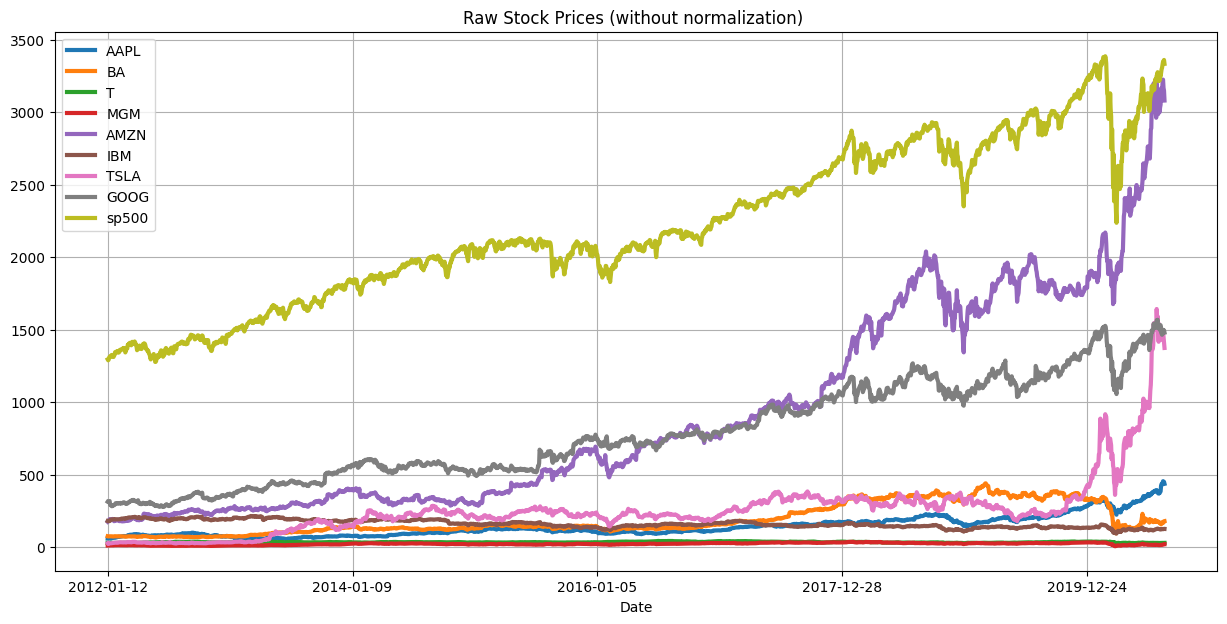

In [114]:
# Plot the data

show_plot(stocks_df, 'Raw Stock Prices (without normalization) ')

**MINI CHALLENGE #2:**
- **Print out normalized (scaled) stock prices**  


In [115]:
def normalize(df):
  x = df.copy()

  for i in x.columns[1:]:
    x[i] = x[i]/x[i][0]
  return x


In [116]:
normalize(stocks_df)

,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,2012-01-13,0.996251,0.987949,0.998340,1.018137,1.014153,0.992301,0.806726,0.992615,0.995052
2,2012-01-17,1.007855,0.996424,1.004316,1.009893,1.032570,0.996954,0.941593,0.998317,0.998587
3,2012-01-18,1.018320,0.994040,1.006972,1.049464,1.076792,1.002880,0.949027,1.005193,1.009680
4,2012-01-19,1.015093,1.000662,1.009960,1.055235,1.105269,0.999834,0.947257,1.015771,1.014666
...,...,...,...,...,...,...,...,...,...,...
2154,2020-08-05,7.313297,2.308039,0.991036,1.378401,18.217644,0.694821,52.567080,4.698347,2.568715
2155,2020-08-06,7.568452,2.280493,0.990704,1.521847,18.331155,0.698532,52.728494,4.782805,2.585226
2156,2020-08-07,7.383066,2.251622,0.996680,1.568838,18.004093,0.692107,51.423361,4.764919,2.586862
2157,2020-08-10,7.490377,2.375977,1.002656,1.784831,17.894390,0.704016,50.214865,4.770052,2.593956


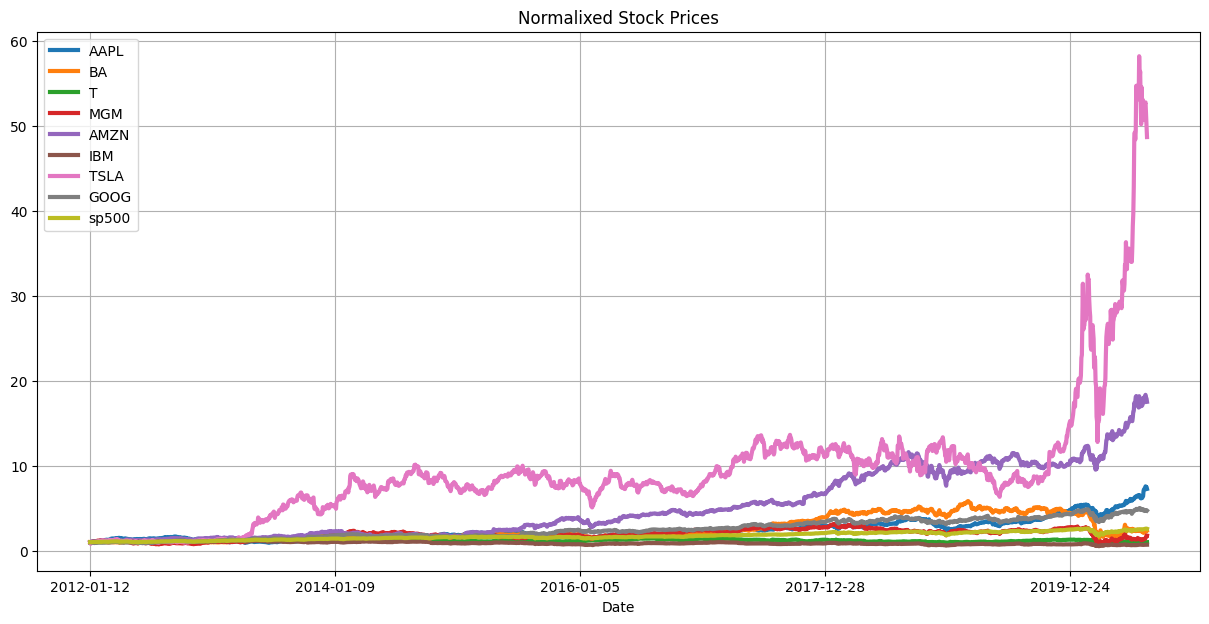

In [117]:
show_plot(normalize(stocks_df), 'Normalixed Stock Prices')

# TASK #4: PERFORM INTERACTIVE DATA VISUALIZATION

In [118]:
# Function to perform an interactive data plotting using plotly express
# Plotly.express module which is imported as px includes functions that can plot interactive plots easily and effectively.
# Every Plotly Express function uses graph objects internally and returns a plotly.graph_objects.Figure instance.

def interctive_plot(df, title):
  fig = px.line(title=title)

  for i in df.columns[1:]:
    fig.add_scatter(x=df['Date'] , y=df[i] , name=i )

  fig.show()

In [119]:
# Plot interactive chart

interctive_plot(stocks_df, 'Prices')


**MINI CHALLENGE #3:**
- **Plot normalized stock data in an interactive way**
- **It seems that most stocks experienced massive drops in 2020, let's assume that you own 100 shares of the S&P500 and you bought them on Feb 19th, 2020. How much did you lose (in $) by March 23rd, 2020?**


In [120]:
interctive_plot(normalize(stocks_df), 'Normalized Prices')

In [121]:
# It seems that most stocks experienced massive drops in 2020, let's assume that you own 100 shares of the S&P500
#  and you bought them on Feb 19th, 2020. How much did you lose (in $) by March 23rd, 2020?

february_prices_sp500_df = pd.DataFrame(stocks_df['sp500'][ stocks_df['Date'] == '2020-02-19'])
march_prices_sp500_df = pd.DataFrame(stocks_df['sp500'][ stocks_df['Date'] == '2020-03-23'])
print(february_prices_sp500_df)
print(march_prices_sp500_df)

dif = (march_prices_sp500_df['sp500'].values[0] - february_prices_sp500_df['sp500'].values[0])* 100
print(dif)

            sp500
2037  3386.149902
            sp500
2060  2237.399902
-114875.0


# TASK #5: CALCULATE INDIVIDUAL STOCKS DAILY RETURNS

In [122]:
# Let's calculate daily return for a single security
# Let's take the S&P500 as an example first

df = stocks_df['sp500']
df

,sp500
0,1295.500000
1,1289.089966
2,1293.670044
3,1308.040039
4,1314.500000
...,...
2154,3327.770020
2155,3349.159912
2156,3351.280029
2157,3360.469971


In [123]:
df_daily_return = df.copy()

for j in range(1, len(df)):
  df_daily_return[j] = ((df[j] - df[j-1])/df[j-1])*100

df_daily_return[0]= 0
df_daily_return

,sp500
0,0.000000
1,-0.494792
2,0.355295
3,1.110793
4,0.493866
...,...
2154,0.642974
2155,0.642770
2156,0.063303
2157,0.274222


**MINI CHALLENGE #4:**
- **Calculate the daily return for Amazon stock.**


In [124]:
df = stocks_df['AMZN']
df


,AMZN
0,175.929993
1,178.419998
2,181.660004
3,189.440002
4,194.449997
...,...
2154,3205.030029
2155,3225.000000
2156,3167.459961
2157,3148.159912


In [125]:
df_daily_return = df.copy()

for j in range(1, len(df)):
  df_daily_return[j] = ((df[j] - df[j-1])/df[j-1])*100

df_daily_return[0]= 0
df_daily_return

,AMZN
0,0.000000
1,1.415339
2,1.815943
3,4.282725
4,2.644634
...,...
2154,2.109065
2155,0.623082
2156,-1.784187
2157,-0.609323


# TASK #6: CALCULATE MULTIPLE STOCKS DAILY RETURNS

In [126]:
# Let's define a function to calculate stocks daily returns (for all stocks)

def daily_return(df):
  df_daily_return = df.copy()

  for i in df.columns[1:]:

    for j in range(1, len(df)):
      df_daily_return[i][j] = ((df[i][j] - df[i][j-1])/df[i][j-1]) * 100

    df_daily_return[i][0] = 0

  return df_daily_return


In [127]:
# Get the daily returns

stocks_daily_return = daily_return(stocks_df)
stocks_daily_return

Streaming output truncated to the last 5000 lines.

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/tmp/ipykernel_2951/2188842334.py:9: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignme

,Date,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
0,2012-01-12,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2012-01-13,-0.374946,-1.205144,-0.166006,1.813685,1.415339,-0.769869,-19.327430,-0.738516,-0.494792
2,2012-01-17,1.164812,0.857909,0.598603,-0.809717,1.815943,0.468852,16.717854,0.574410,0.355295
3,2012-01-18,1.038382,-0.239234,0.264463,3.918367,4.282725,0.594448,0.789470,0.688856,1.110793
4,2012-01-19,-0.316937,0.666134,0.296736,0.549882,2.644634,-0.303752,-0.186494,1.052283,0.493866
...,...,...,...,...,...,...,...,...,...,...
2154,2020-08-05,0.362467,5.579446,-0.533156,0.000000,2.109065,-0.309917,-0.133153,0.589774,0.642974
2155,2020-08-06,3.488923,-1.193483,-0.033501,10.406699,0.623082,0.534082,0.307062,1.797626,0.642770
2156,2020-08-07,-2.449458,-1.265966,0.603217,3.087768,-1.784187,-0.919762,-2.475194,-0.373974,0.063303
2157,2020-08-10,1.453480,5.522880,0.599604,13.767729,-0.609323,1.720552,-2.350092,0.107728,0.274222


**MINI CHALLENGE #5:**
- **Plot the returns vs. time using both static and interactive plots**
- **What is the maximum daily return in % values**

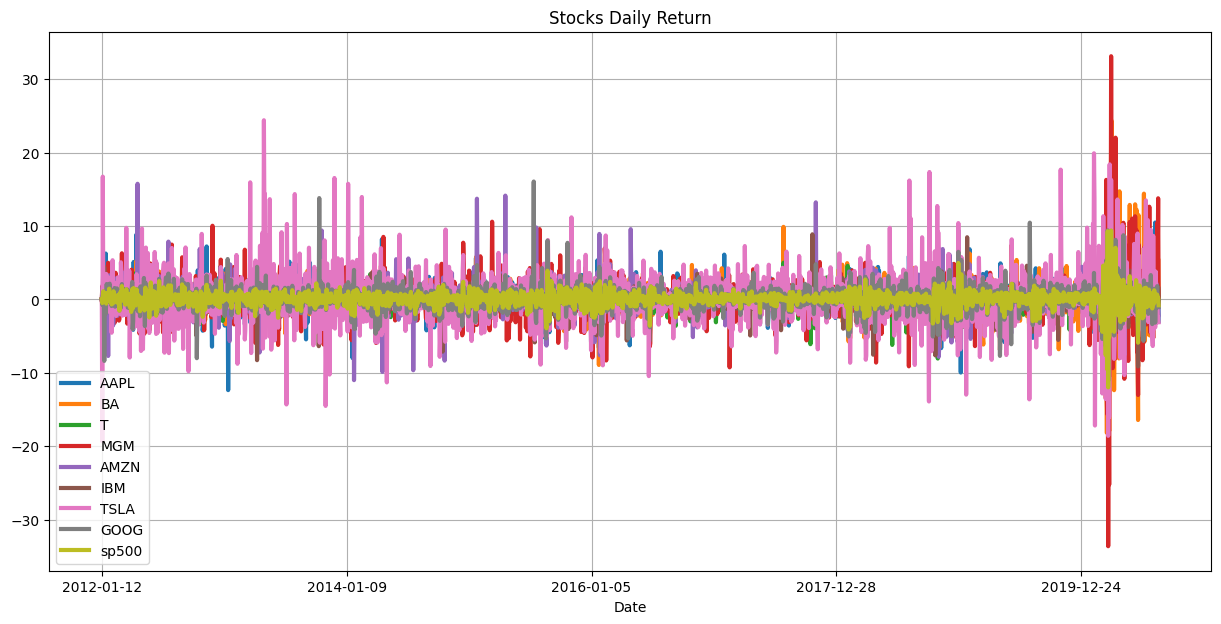

In [128]:
show_plot(stocks_daily_return, 'Stocks Daily Return')

In [129]:
interctive_plot(stocks_daily_return, 'Interactive Stocks Daily Return')


# TASK #7: CALCULATE THE CORRELATIONS BETWEEN DAILY RETURNS

In [130]:
# Daily Return Correlation

cm = stocks_daily_return.drop(columns=['Date']).corr()


<Axes: >

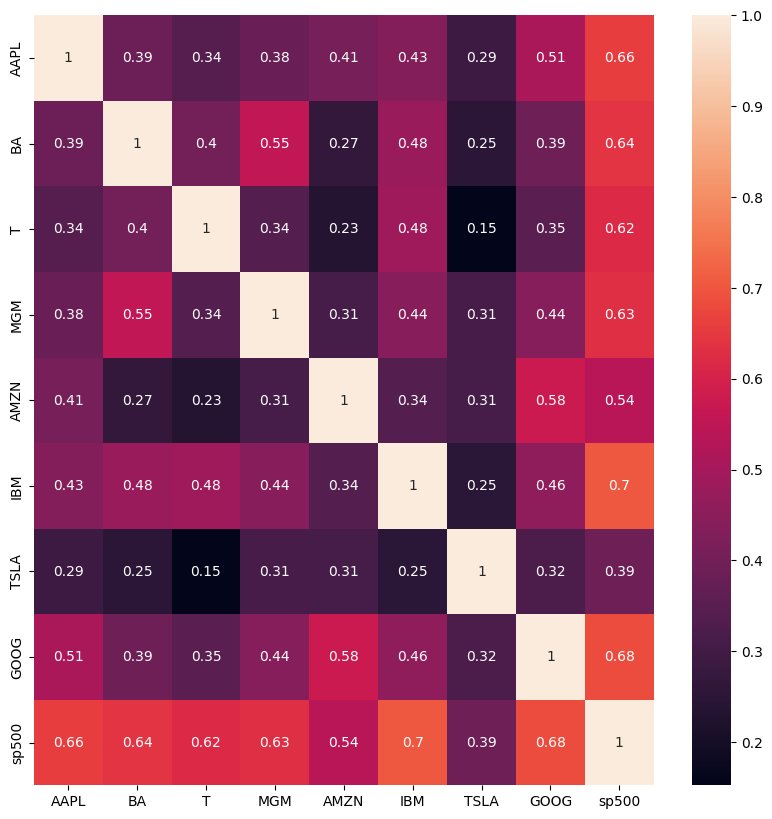

In [131]:
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True)

**MINI CHALLENGE #6:**
- **What are the top 2 stocks that are positively correlated with the S&P500?**
- **What is the correlation between Amazon and Boeing? Comment on your answer**
- **What is the correlation between MGM and Boeing? Comment on your answer**

In [132]:
# What are the top 2 stocks that are positively correlated with the S&P500?
# IBM and GOOG

# What is the correlation between Amazon and Boeing? Comment on your answer
# 0.27 (not correlated at all, totaly different industries)

# What is the correlation between MGM and Boeing? Comment on your answer
# 0.55

# TASK #8: PLOT THE HISTOGRAM FOR DAILY RETURNS

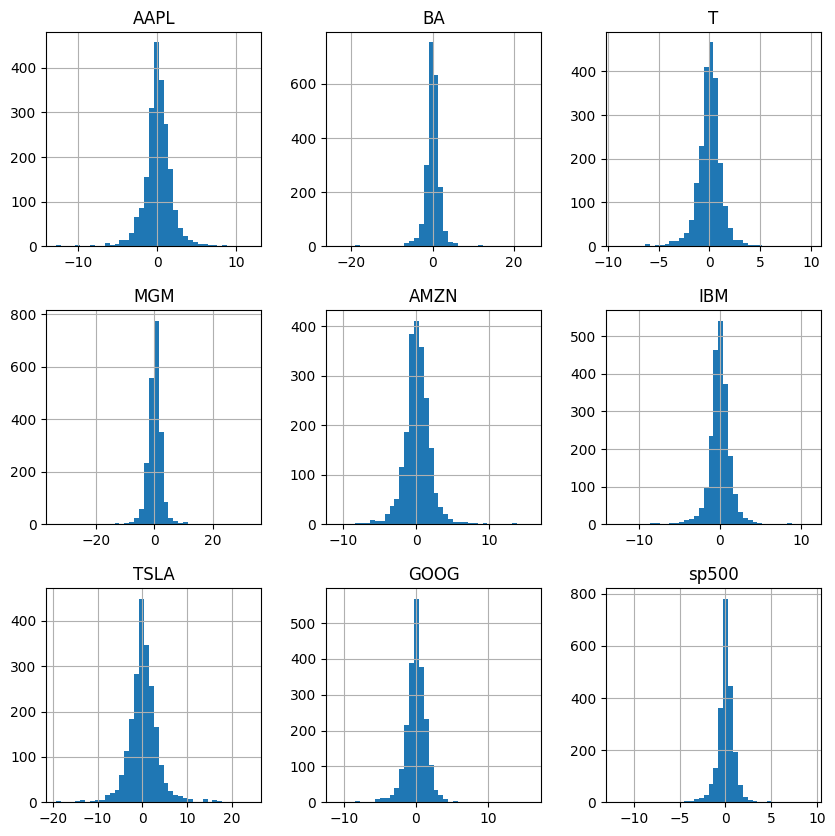

In [133]:
# Histogram of daily returns
# Stock returns are normally distributed with zero mean
# Notice how Tesla Standard deviation is high indicating a more volatile stock

stocks_daily_return.hist(figsize=(10, 10), bins=40);


**MINI CHALLENGE #7:**
- **Based on the histogram, which of the following stocks are more risky? T or TSLA**

In [134]:
# Tesla is more risky (-20 to 20)

In [135]:
# Group all data returns together in a list
# Make a copy of the daily returns dataframe

df_hist = stocks_daily_return.copy()

df_hist = df_hist.drop(columns=['Date'])

data = []

for i in df_hist.columns:
  data.append(stocks_daily_return[i].values)

data

[array([ 0.        , -0.37494578,  1.16481192, ..., -2.44945751,
         1.45347999, -2.9739868 ]),
 array([ 0.        , -1.20514366,  0.85790887, ..., -1.26596576,
         5.52287953,  0.40131597]),
 array([ 0.        , -0.16600597,  0.59860326, ...,  0.60321716,
         0.5996036 ,  0.        ]),
 array([ 0.        ,  1.81368508, -0.8097166 , ...,  3.08776831,
        13.76772918, -0.69284065]),
 array([ 0.        ,  1.41533854,  1.8159433 , ..., -1.78418726,
        -0.60932259, -2.14379167]),
 array([ 0.        , -0.76986928,  0.46885241, ..., -0.91976211,
         1.72055219, -0.28322004]),
 array([  0.        , -19.32743009,  16.71785359, ...,  -2.47519409,
         -2.35009162,  -3.1143992 ]),
 array([ 0.        , -0.73851634,  0.57441015, ..., -0.37397414,
         0.10772812, -1.05474435]),
 array([ 0.        , -0.49479228,  0.35529545, ...,  0.06330295,
         0.27422185, -0.79691324])]

In [136]:
# Plotly's Python API contains a super pwerful module known as figure factory module
# Figure factory module includes wrapper functions that create unique chart types such as interactive subplots
# Check this out for more information: https://plotly.com/python/figure-factory-subplots/
# Notice how Boeing, Tesla and MGM gains are losses are sometimes extreme! This will indicate a more risky investment and will be quantified later using Sharpe Ratio


fig = ff.create_distplot(data, df_hist.columns)
fig.show()

# EXCELLENT JOB!

# **MINI CHALLENGE SOLUTIONS**

**MINI CHALLENGE #1 SOLUTION:**
- **What is the average return of the S&P500?**
- **What is the maximum price for AMZN stock over the specified time period?**

In [137]:
stocks_df.drop(columns=['Date']).mean()

,0
AAPL,140.819823
BA,189.942700
T,35.162899
MGM,23.105743
AMZN,915.665665
IBM,161.853001
TSLA,259.600815
GOOG,783.712512
sp500,2218.749554


In [138]:
# Get the standard deviation of stocks (Volatility)
stocks_df.std()

TypeError: could not convert string to float: '2012-01-12'

In [ ]:
# Statistical data of the dataframe
stocks_df.describe()

**MINI CHALLENGE #2 SOLUTION:**
- **Print out normalized (scaled) stock prices**  


In [ ]:
# Function to normalize the prices based on the initial price
# The function simply divides every stock by it's price at the start date (i.e.: Date = 2012-01-12)
def normalize(df):
  x = df.copy()

  # Loop through each stock (while ignoring time columns with index 0)
  for i in x.columns[1:]:
    x[i] = x[i]/x[i][0]
  return x

In [ ]:
# Plot normalized data
# Notice the massive gains in Tesla Stock compared to Amazon (second place)
show_plot(normalize(stocks_df), 'NORMALIZED STOCK PRICES')

**MINI CHALLENGE #3 SOLUTION:**
- **Plot normalized stock data in an interactive way**
- **It seems that most stocks experienced massive drops in 2020, let's assume that you own 100 shares of the S&P500 and you bought them on Feb 19th, 2020. How much did you lose (in $) by March 23rd, 2020?**


In [ ]:
# Plot normalized interactive chart
interactive_plot(normalize(stocks_df), 'Normalized Prices')


In [ ]:
# S&P500 dropped from $3386.15 on Feb 19th, 2020 to $2237.4 by March 23rd, 2020
# Net loss = $3386.15 - $2237.4 = $1148.75

**MINI CHALLENGE #4 SOLUTION:**
- **Calculate the daily return for Amazon stock.**


In [ ]:
df = stocks_df['AMZN']

**MINI CHALLENGE #5 SOLUTION:**
- **Plot the returns vs. time using both static and interactive plots**
- **What is the maximum daily return in % values**

In [ ]:
# Plot the daily returns
# Notice huge drops in MGM around March 2020 (Pandemic effect)
show_plot(stocks_daily_return, 'STOCKS DAILY RETURNS')

In [ ]:
# Plot the interactive chart
# Zoom in to view the sharp decline during March 2020
interactive_plot(stocks_daily_return, 'STOCKS DAILY RETURNS')

**MINI CHALLENGE #6 SOLUTION:**
- **What are the top 2 stocks that are positively correlated with the S&P500?**
- **What is the correlation between Amazon and Boeing? Comment on your answer**
- **What is the correlation between MGM and Boeing? Comment on your answer**

In [ ]:
# Strong positive correlation between S&P500 and Google
# Strong positive correlation between S&P500 and IBM
# Almost no correlation between Amazon and Beoing - totally different sectors
# Some correlation exists between MGM and Boeing (Hotel and Airlines)

**MINI CHALLENGE #7 SOLUTION:**
- **Based on the histogram, which of the following stocks are more risky? T or TSLA**

In [ ]:
# Tesla standard deviation is much larger compared to T indicating a more risky security